# Adversarial Training

In [1]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset, TensorDataset
import torch.optim as optim
# trochvision is part of PyTorch consisting of models and datasets for computer vision
import torchvision
from torchvision import datasets, transforms
from torchvision.datasets import ImageFolder
from torchvision.models import vgg16

In [2]:
# Download the dataset
!wget https://www.idahofallshighered.org/vakanski/Codes_Data/imagenette_folders.zip

--2026-03-19 17:26:04--  https://www.idahofallshighered.org/vakanski/Codes_Data/imagenette_folders.zip
Resolving www.idahofallshighered.org (www.idahofallshighered.org)... 50.6.2.30
Connecting to www.idahofallshighered.org (www.idahofallshighered.org)|50.6.2.30|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 106910653 (102M) [application/zip]
Saving to: ‘imagenette_folders.zip’

imagenette_folders. 100%[===================>] 101.96M   165MB/s    in 0.6s    

2026-03-19 17:26:05 (165 MB/s) - ‘imagenette_folders.zip’ saved [106910653/106910653]



In [3]:
# Uncompress the dataset
!unzip -uq 'imagenette_folders.zip' -d 'sample_data/'

In [4]:
# load the dataset
transform = transforms.Compose([transforms.Resize((128, 128)), transforms.ToTensor()])

train_dataset = ImageFolder(root='sample_data/imagenette_folders/train/', transform=transform)
test_dataset = ImageFolder(root='sample_data/imagenette_folders/val', transform=transform)

train_dataloader = DataLoader(train_dataset, shuffle=True, batch_size=64)
test_dataloader = DataLoader(test_dataset, shuffle=False, batch_size=64)

In [5]:
from sklearn.model_selection import train_test_split

# Split the train dataset into train and validation subsets
train_indices, val_indices = train_test_split(range(len(train_dataset)), test_size=0.2, random_state=123)

# Create training and validation subsets
train_dataset_subset = Subset(train_dataset, train_indices)
val_dataset = Subset(train_dataset, val_indices)

In [6]:
# Create training, testing, and validation dataloaders for iterating over the datasets
train_dataloader = DataLoader(train_dataset_subset, shuffle=True, batch_size=64)
test_dataloader = DataLoader(test_dataset, shuffle=False, batch_size=64)
val_dataloader = DataLoader(val_dataset, shuffle=False, batch_size=64)

In [7]:
print(len(train_dataset))
print(len(test_dataset))
print(len(val_dataset))

9469
3925
1894


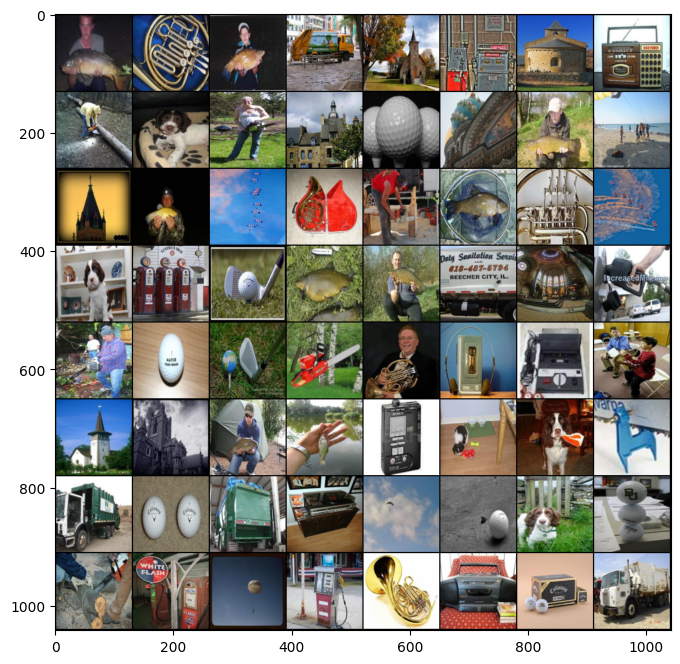

In [8]:
# show several images
def imshow(img):
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# get a batch of random training images and labels
images, labels = next(iter(train_dataloader))

# show images
plt.figure(figsize=(8,8))
imshow(torchvision.utils.make_grid(images))

# Model Training and Validation

In [9]:
# Import pretrained VGG16
model = vgg16(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 189MB/s]


In [10]:
# Change the output in the last layer to 10 classes
model.classifier._modules['6'] = nn.Linear(4096, 10)

In [11]:
# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [13]:
# Move the model to the GPU
model.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [14]:
# function to train the model for one epoch on the given set
def train(model, train_loader, criterion, optimizer, epoch):
    running_loss, total, sum_correct = 0.0, 0, 0

    # indicate this is a training step
    model.train()

    for i, data in enumerate(train_loader):
        images, labels = data
        labels = labels.type(torch.LongTensor)
        images, labels = images.to(device), labels.to(device)

        # forward + loss + backward + update
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # calculate loss and accuracy
        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        predicted = outputs.argmax(dim=1)
        sum_correct += (predicted == labels).sum().item()
        total += batch_size

    # return the accuracy and loss
    return sum_correct/total, running_loss/total


# function to evaluate the model on the given set
def validate(model, val_loader, criterion):
    running_loss, total, sum_correct = 0.0, 0, 0

    # indicate this is an evaluation step
    model.eval()

    with torch.no_grad():
        for i, data in enumerate(val_loader):
            images, labels = data
            labels = labels.type(torch.LongTensor)
            images, labels = images.to(device), labels.to(device)

            # Compute the output: forward pass only
            outputs = model(images)
            loss = criterion(outputs, labels)

            # calculate loss and accuracy
            batch_size = images.size(0)
            running_loss += loss.item() * batch_size
            predicted = outputs.argmax(dim=1)
            sum_correct += (predicted == labels).sum().item()
            total += batch_size

    # return the accuracy and loss
    return sum_correct/total, running_loss/total

In [15]:
# training loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [16]:
# total number of training epochs
epoch_num = 10

# initialize variables to save the training and validation loss and accuracy
training_loss_plot = []
training_accuracy_plot = []
val_loss_plot = []
val_accuracy_plot = []

import datetime
now = datetime.datetime.now
t = now()

# loop over the number of epochs
for epoch in range(epoch_num):

    # train for one epoch: return accuracy and loss
    tr_accuracy, tr_loss = train(model, train_dataloader, criterion, optimizer, epoch)

    # evaluate after each epoch: return accuracy and loss
    val_accuracy, val_loss = validate(model, val_dataloader, criterion)

    # append the accuracies and losses after each epoch
    training_accuracy_plot.append(tr_accuracy)
    training_loss_plot.append(tr_loss)
    val_accuracy_plot.append(val_accuracy)
    val_loss_plot.append(val_loss)

    # Display after each epoch
    print(f'Epoch: {epoch + 1}/{epoch_num}\t Training loss: {tr_loss:.3f}\t',
              f'Training accuracy: {100*tr_accuracy:2.3f}\t Validation accuracy: {100*val_accuracy:2.3f}')

print('Training time: %s' % (now() - t))

Epoch: 1/10	 Training loss: 0.398	 Training accuracy: 87.670	 Validation accuracy: 92.872
Epoch: 2/10	 Training loss: 0.130	 Training accuracy: 95.828	 Validation accuracy: 94.403
Epoch: 3/10	 Training loss: 0.093	 Training accuracy: 96.937	 Validation accuracy: 92.925
Epoch: 4/10	 Training loss: 0.087	 Training accuracy: 97.360	 Validation accuracy: 93.083
Epoch: 5/10	 Training loss: 0.038	 Training accuracy: 98.957	 Validation accuracy: 93.770
Epoch: 6/10	 Training loss: 0.031	 Training accuracy: 99.036	 Validation accuracy: 94.351
Epoch: 7/10	 Training loss: 0.046	 Training accuracy: 98.693	 Validation accuracy: 92.027
Epoch: 8/10	 Training loss: 0.022	 Training accuracy: 99.393	 Validation accuracy: 91.235
Epoch: 9/10	 Training loss: 0.041	 Training accuracy: 98.931	 Validation accuracy: 93.770
Epoch: 10/10	 Training loss: 0.037	 Training accuracy: 98.891	 Validation accuracy: 93.611
Training time: 0:08:53.890007


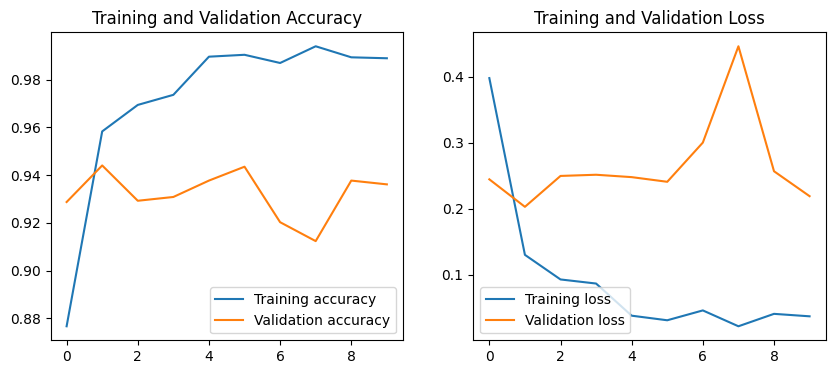

In [17]:
# plot the accuracy and loss for the training and validation datasets
plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
plt.plot(training_accuracy_plot)
plt.plot(val_accuracy_plot)
plt.legend(['Training accuracy', 'Validation accuracy'])
plt.title('Training and Validation Accuracy')
plt.subplot(1,2,2)
plt.plot(training_loss_plot)
plt.plot(val_loss_plot)
plt.legend(['Training loss', 'Validation loss'])
plt.title('Training and Validation Loss')
plt.show()

In [18]:
# calculate the accuracy and loss on the test dataset
test_accuracy, test_loss = validate(model, test_dataloader, criterion)
print(f'Test dataset accuracy: {100*test_accuracy:2.3f}')

Test dataset accuracy: 92.739


# Generate Advesarial Examples

In [19]:
# Install the Cleverhans library (provides adversarial attacks)
!pip install -qq git+http://github.com/tensorflow/cleverhans.git#egg=cleverhans

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 3.9 MB/s eta 0:00:00


In [20]:
import cleverhans

from cleverhans.torch.attacks.projected_gradient_descent import projected_gradient_descent

In [21]:
# PGD attack on the test dataset
correct = 0
total = 0
adv_images_list = []
labels_list = []
epsilon = 10/255.

for data in test_dataloader:
    images, labels = data
    images = images.cuda()
    labels = labels.cuda()
    adversarial_images = projected_gradient_descent(model_fn=model, x=images, eps=epsilon, eps_iter=2.5*epsilon/20, nb_iter=5, norm=np.inf)
    outputs = model(adversarial_images)
    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()
    adv_images_list.append(adversarial_images.detach().cpu())
    labels_list.append(labels.cpu())

accuracy = correct / total
print("Accuracy:", accuracy)

Accuracy: 0.06522292993630573


In [22]:
# Convert lists to tensors
adv_images_tensor = torch.cat(adv_images_list, dim=0)
adv_labels_tensor = torch.cat(labels_list, dim=0)

# Create a dataset from tensors
pgd_test_dataset = TensorDataset(adv_images_tensor, adv_labels_tensor)

# Create a DataLoader
pgd_test_dataloader = DataLoader(pgd_test_dataset, batch_size=64, shuffle=False)

# Calculate the accuracy of the PGD attack on test dataset
pgd_test_accuracy, pgd_test_loss = validate(model, pgd_test_dataloader, criterion)
print(f'PGD adversarial examples accuracy: {100*pgd_test_accuracy:2.3f}')

PGD adversarial examples accuracy: 6.522


In [23]:
# Check the number of adversarial test images
len(pgd_test_dataset)

3925

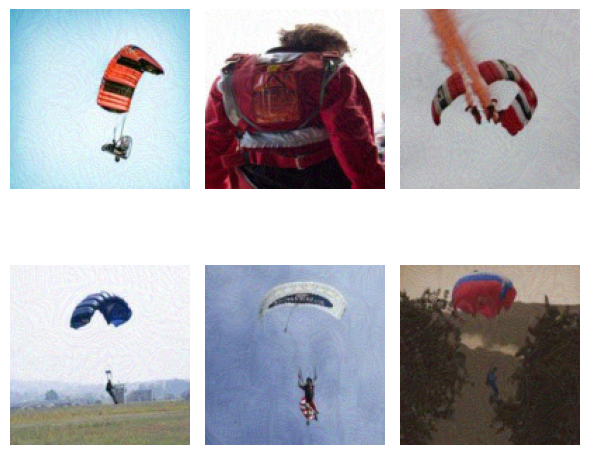

In [24]:
# Plot the first 6 images
fig, axes = plt.subplots(2, 3, figsize=(6, 6))
axes = axes.flatten()

for i in range(6):
    ax = axes[i]
    img = adversarial_images[i].detach().cpu()
    ax.imshow(np.transpose(img, (1, 2, 0)))
    ax.axis('off')

plt.tight_layout()
plt.show()

In [25]:
# Apply PGD attack on the validation dataset (to be used during adversarial training)
correct = 0
total = 0
adv_images_list = []
labels_list = []
epsilon = 10/255.

for data in val_dataloader:
    images, labels = data
    images = images.cuda()
    labels = labels.cuda()
    adversarial_images = projected_gradient_descent(model_fn=model, x=images, eps=epsilon, eps_iter=2.5*epsilon/20, nb_iter=5, norm=np.inf)
    outputs = model(adversarial_images)
    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()
    adv_images_list.append(adversarial_images.detach().cpu())
    labels_list.append(labels.cpu())

accuracy = correct / total
print("Accuracy:", accuracy)

Accuracy: 0.061246040126715945


In [26]:
# Convert lists to tensors
adv_images_tensor = torch.cat(adv_images_list, dim=0)
adv_labels_tensor = torch.cat(labels_list, dim=0)

# Create a dataset from tensors
pgd_val_dataset = TensorDataset(adv_images_tensor, adv_labels_tensor)

# Create a DataLoader
pgd_val_dataloader = DataLoader(pgd_val_dataset, batch_size=64, shuffle=False)

# Calculate the accuracy of the PGD attack on validation dataset
pgd_val_accuracy, pgd_val_loss = validate(model, pgd_val_dataloader, criterion)
print(f'PGD adversarial examples accuracy: {100*pgd_val_accuracy:2.3f}')

PGD adversarial examples accuracy: 6.125


In [27]:
# Check the number of adversarial validation images
len(pgd_val_dataset)

1894

# Adversarial Training

In [28]:
# Use a lower learning rate for adversarial fine-tuning
adv_optimizer = optim.Adam(model.parameters(), lr=1e-5)

In [29]:
def adversarial_training(model, train_loader, val_loader, pgd_val_dataloader, optimizer, epochs=20, epsilon=10/255.):

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # Generate FGSM adversarial examples
            adv_images = projected_gradient_descent(model_fn=model, x=images,
                  eps=epsilon, eps_iter=2.5*epsilon/20, nb_iter=5, norm=np.inf)

            # Forward pass on adversarial examples (Madry et al.)
            outputs = model(adv_images)
            loss = criterion(outputs, labels)

            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        # Evaluate the performance on clean validation dataset at end of each epoch
        clean_val_accuracy, clean_val_loss = validate(model, val_dataloader, criterion)

        # Evaluate the performance on adversarial validation dataset at end of each epoch
        pgd_val_accuracy, pgd_val_loss = validate(model, pgd_val_dataloader, criterion)

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss / len(train_loader):.4f}, "
              f"Clean Val Accuracy: {100*clean_val_accuracy:.3f}%, "
              f"Adversarial Val Accuracy: {100*pgd_val_accuracy:.3f}%")

In [30]:
# Advsarial training
t = now()
adversarial_training(model, train_dataloader, val_dataloader, pgd_val_dataloader, adv_optimizer, epochs=20, epsilon=10/255.)
print('Time for adversarial training: %s' % (now() - t))

Epoch [1/20], Loss: 5.3478, Clean Val Accuracy: 82.154%, Adversarial Val Accuracy: 6.811%
Epoch [2/20], Loss: 2.3319, Clean Val Accuracy: 83.369%, Adversarial Val Accuracy: 8.501%
Epoch [3/20], Loss: 2.2660, Clean Val Accuracy: 85.639%, Adversarial Val Accuracy: 8.659%
Epoch [4/20], Loss: 2.2645, Clean Val Accuracy: 85.744%, Adversarial Val Accuracy: 9.240%
Epoch [5/20], Loss: 2.2503, Clean Val Accuracy: 86.167%, Adversarial Val Accuracy: 10.137%
Epoch [6/20], Loss: 2.2429, Clean Val Accuracy: 86.167%, Adversarial Val Accuracy: 10.507%
Epoch [7/20], Loss: 2.2394, Clean Val Accuracy: 86.325%, Adversarial Val Accuracy: 11.140%
Epoch [8/20], Loss: 2.2363, Clean Val Accuracy: 86.484%, Adversarial Val Accuracy: 11.616%
Epoch [9/20], Loss: 2.2417, Clean Val Accuracy: 86.589%, Adversarial Val Accuracy: 12.777%
Epoch [10/20], Loss: 2.2338, Clean Val Accuracy: 86.484%, Adversarial Val Accuracy: 14.150%
Epoch [11/20], Loss: 2.2211, Clean Val Accuracy: 85.850%, Adversarial Val Accuracy: 16.631%
E

In [31]:
# Calculate the accuracy on the clean test dataset
clean_test_accuracy, test_loss = validate(model, test_dataloader, criterion)
print(f'Clean test dataset accuracy: {100*clean_test_accuracy:2.3f}')

Clean test dataset accuracy: 85.987


In [32]:
# Calculate the accuracy on the PGD adversarial exmaples
pgd_test_accuracy, adv_test_loss = validate(model, pgd_test_dataloader, criterion)
print(f'PGD adversarial examples on test dataset accuracy: {100*pgd_test_accuracy:2.3f}')

PGD adversarial examples on test dataset accuracy: 83.898
